In [1]:
import torch
from torch.utils.data import Dataset
import torchaudio
from IPython.display import Audio, display
import librosa
from torch import nn
from torch.utils.data import DataLoader
import os
import matplotlib.pyplot as plt
import numpy as np
import glob
import torch.nn.functional as F
from numpy import random

In [2]:
###################### 训练前准备 ######################
#读取训练文件
filelist=[] # to store noisy audio
labellist=[] # to store clean audio 

noisypath="./data/noizeus/withnoise/"
cleanpath='./data/noizeus/clean/'

noiseyfolders=os.listdir(noisypath)
cleanfolders=os.listdir(cleanpath)

for folder in noiseyfolders:
    audios=os.listdir(noisypath+folder+"/")
    for audio in audios:
        filelist.append(noisypath+folder+"/"+audio)
        
for audio in cleanfolders:
    labellist.append(cleanpath+audio)

print('read {} noisy files.'.format(len(filelist)))
print('read {} clean files.'.format(len(labellist)))

# 语谱图函数
def spectrogram(wav):
    win_length=256
    n_fft=256
    hop_length=64
    wav = wav.squeeze()
    S = torch.stft(wav, n_fft=n_fft, hop_length=hop_length,
                   win_length=win_length, window=torch.hann_window(window_length=win_length),
                   center=True, return_complex=True)   
    magnitude = torch.abs(S)        # 振幅
    phase = torch.exp(1j * torch.angle(S))  # 相位
    return magnitude, phase

#构建pytorch数据集
class mydataset(Dataset):
    def __init__(self,filelist,labellist):
        self.filelist=filelist
        self.labellist=labellist
        self.win_length=256
        self.hop_length=64
        self.n_fft=256
        
    def __len__(self):
        return len(self.filelist*2)

    def __getitem__(self, idx):
        f=idx//2
        n=idx%2
        
        noised_waveform,_= torchaudio.load(self.filelist[f])
        noised_waveform = noised_waveform[0][:16704]#[16704,]
        noised_waveform=noised_waveform.unsqueeze(0)#[1,16704]
        
        clean_waveform,_=torchaudio.load(self.labellist[int(filelist[f][-6:-4])-1])
        clean_waveform = clean_waveform[0][:16704]#[16704,]
        clean_waveform=clean_waveform.unsqueeze(0)#[1,16704]
        
        noise_waveform=noised_waveform-clean_waveform
        
        noised_mag ,_ = spectrogram(noised_waveform)
        clean_mag ,_ = spectrogram(clean_waveform)
        noise_mag,_ = spectrogram(noise_waveform)
        
        #语谱图shape[129, 258],截成两张[129,129]
        postion=n
        length=129
        sliced_noised=noised_mag[:,length*postion:length*(postion+1)]
        sliced_clean=clean_mag[:,length*(postion):length*(postion+1)]
        sliced_noise=noise_mag[:,length*(postion):length*(postion+1)]
        #single_frame_noised_mag= sliced_noised[:,length:2*length]
        
        _eps = torch.finfo(torch.float).eps  # 防止分母出现0
        mask_IRM = torch.sqrt(sliced_clean ** 2/(sliced_noise ** 2+sliced_clean ** 2+_eps))  # IRM，模型输出
        label=mask_IRM #掩蔽
        return sliced_noised.unsqueeze(0),label.unsqueeze(0)
    
#实例化MyDataset类
dataset=mydataset(filelist,labellist)
#查看dataset值
print(dataset[2][0].shape)
print(dataset[2][1].shape)

# 检查设备
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

read 450 noisy files.
read 30 clean files.
torch.Size([1, 129, 129])
torch.Size([1, 129, 129])
cuda


In [3]:
###################### 网络设置 ######################
#按照0.8 0.2比例分割训练集和验证集
length=len(dataset)
train_size = int(0.8 * len(dataset))
validate_size = len(dataset) - train_size
train_set,validate_set=torch.utils.data.random_split(dataset,[train_size,validate_size])
batch_size=16
train_dataloader = DataLoader(train_set, batch_size=batch_size,shuffle=True)
validate_dataloader = DataLoader(validate_set, batch_size=batch_size,shuffle=True)

#8层GRU 输入格式要求[batch channel sequence feature]
class RNN(nn.Module):
    def __init__(self):
        super(RNN, self).__init__()
        self.gru1=nn.GRU(129,hidden_size=1024,num_layers=1,batch_first=True) # 第1层（129->1024）
        self.gru2=nn.GRU(1024,hidden_size=1024,num_layers=14,batch_first=True) # 第2-（1024->1024）
        self.gru3=nn.GRU(1024,hidden_size=129,num_layers=1,batch_first=True) # 第8层（1024->129）
        self.sig=nn.Sigmoid() # 通过 Sigmoid激活函数 输出（值域 [0,1]，适合概率或掩码预测）
         
    def forward(self, x):
        n_channels, n_f_bins, n_frame_size = x.shape[-3],x.shape[-2],x.shape[-1]
        gru_in = x.reshape(-1, n_channels * n_f_bins, n_frame_size).transpose(-1,-2)
        # 1)合并通道与特征维度：将 (B, C, S, F) 合并为 (B, C*F, S)。
        # 2)转置序列与特征维度：调整为 (B, S, C*F)，满足 PyTorch GRU 的输入格式 (batch, seq_len, input_size)。
        gru_out,_ = self.gru1(gru_in) # (B, S, C*F) → (B, S, 1024)
        gru_out,_ = self.gru2(gru_out) # (B, S, 1024) → (B, S, 1024)
        gru_out,_ = self.gru3(gru_out) # (B, S, 1024) → (B, S, 129)
        gru_out = gru_out.transpose(-1,-2).reshape(-1, n_channels, n_f_bins, n_frame_size)
        out=self.sig(gru_out)
        # 1)恢复序列与特征维度：转置为 (B, 129, S)。
        # 2)拆分通道与特征维度：重塑为原始输入形状 (B, C, F, S)。
        return out

model = RNN().to(device)

#查看输出shape
x=torch.rand([16,1,129,129]).to(device) 
print(model)
print(model(x).shape)

RNN(
  (gru1): GRU(129, 1024, batch_first=True)
  (gru2): GRU(1024, 1024, num_layers=14, batch_first=True)
  (gru3): GRU(1024, 129, batch_first=True)
  (sig): Sigmoid()
)
torch.Size([16, 1, 129, 129])


In [4]:
###################### 训练参数设置 ######################
# 损失函数
loss_fn = nn.MSELoss(reduction='mean')

# 优化器
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4,)

# 训练函数
def train(dataloader, model, loss_fn, optimizer):
    # 初始化
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)
        # 计算损失函数
        pred = model(X)
        loss = loss_fn(pred, y)
        # 反向传播
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        # 训练日志打印
        if batch % 10 == 0:
            loss, current = loss.item(), batch * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

# 测试函数
def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
    test_loss /= num_batches
    print(f"Test Error: \n Avg loss: {test_loss:>8f} \n")

In [5]:
###################### 网络训练 ######################
# 如果需要加载已有模型参数，取消注释
# model.load_state_dict(torch.load('./model/rnn_gru.pt',map_location=device))

epochs = 5
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(train_dataloader, model, loss_fn, optimizer)
    test(validate_dataloader, model, loss_fn)
print("Done!")

Epoch 1
-------------------------------
loss: 0.137933  [    0/  720]
loss: 0.118885  [  160/  720]
loss: 0.104164  [  320/  720]
loss: 0.119521  [  480/  720]
loss: 0.115634  [  640/  720]
Test Error: 
 Avg loss: 0.113023 

Epoch 2
-------------------------------
loss: 0.107506  [    0/  720]
loss: 0.117149  [  160/  720]
loss: 0.103497  [  320/  720]
loss: 0.112113  [  480/  720]
loss: 0.114051  [  640/  720]
Test Error: 
 Avg loss: 0.113595 

Epoch 3
-------------------------------
loss: 0.112101  [    0/  720]
loss: 0.112868  [  160/  720]
loss: 0.110215  [  320/  720]
loss: 0.117762  [  480/  720]
loss: 0.116979  [  640/  720]
Test Error: 
 Avg loss: 0.112559 

Epoch 4
-------------------------------
loss: 0.113837  [    0/  720]
loss: 0.114427  [  160/  720]
loss: 0.116269  [  320/  720]
loss: 0.118738  [  480/  720]
loss: 0.109933  [  640/  720]
Test Error: 
 Avg loss: 0.111453 

Epoch 5
-------------------------------
loss: 0.112556  [    0/  720]
loss: 0.107871  [  160/  720]


In [6]:
###################### 保存模型 ######################
if not os.path.exists('./model'):
    os.makedirs('./model')
torch.save(model.state_dict(),"./model/gru1.pt")

In [7]:
###################### 绘图函数 ######################
# 绘制语谱图
def plot_spectrogram(spec, title=None, ylabel='freq_bin', aspect='auto', xmax=None,
                     if_log=True):
    fig, axs = plt.subplots(1, 1)
    axs.set_title(title or 'Spectrogram (db)')
    axs.set_ylabel(ylabel)
    axs.set_xlabel('frame')
    if if_log:
        spec = librosa.power_to_db(spec,ref=np.max)
    im = axs.imshow(spec, origin='lower', aspect=aspect,cmap='jet')
    if xmax:
        axs.set_xlim((0, xmax))
    fig.colorbar(im, ax=axs)
    plt.show(block=False)

#播放试听
def play_audio(waveform, sample_rate):
    waveform = waveform.numpy()

    num_channels, num_frames = waveform.shape
    if num_channels == 1:
        display(Audio(waveform[0], rate=sample_rate))
    elif num_channels == 2:
        display(Audio((waveform[0], waveform[1]), rate=sample_rate))
    else:
        raise ValueError("Waveform with more than 2 channels are not supported.")

# # 绘制target语谱图
# c=validate_set[0][1][0]/validate_set[0][0][0]
# c[c>1]=1
# plot_spectrogram(c,if_log=False,title='target',xmax=120) 

# # 绘制带噪语谱图
# s=validate_set[0][0]
# print(s.shape)
# plot_spectrogram(s[0],xmax=120) 

# # 绘制降噪后语谱图
# irm=model(s.to(device).unsqueeze(0))
# denoised=irm*s.to(device)
# plot_spectrogram(denoised[0][0].detach().cpu(),xmax=120)

In [8]:
###################### 测试环节 ######################
model = RNN().to(device)
model.load_state_dict(torch.load('./model/gru1.pt',map_location=device))

#从测试音频中挑选一个进行降噪
num=1 #可以为1，2，3
noised_waveform,_= torchaudio.load('./data/mynoise{}.wav'.format(num))
noised_waveform=noised_waveform[:,:16704]
mag,phase=spectrogram(noised_waveform)
phase = phase.to(device)
mag1=mag[:,:129].to(device)
denoised_mag1=mag1*model(mag1.unsqueeze(0).unsqueeze(0))[0]
mag2=mag[:,129:].to(device)
denoised_mag2=mag2*model(mag2.unsqueeze(0).unsqueeze(0))[0]
denoised_mag=torch.cat([denoised_mag1,denoised_mag2],dim=2)
complex_stft = (denoised_mag * phase).detach().cpu()
waveform=torch.istft(complex_stft, n_fft=256, hop_length=64, win_length=256,
                          window=torch.hann_window(window_length=256),center=True)

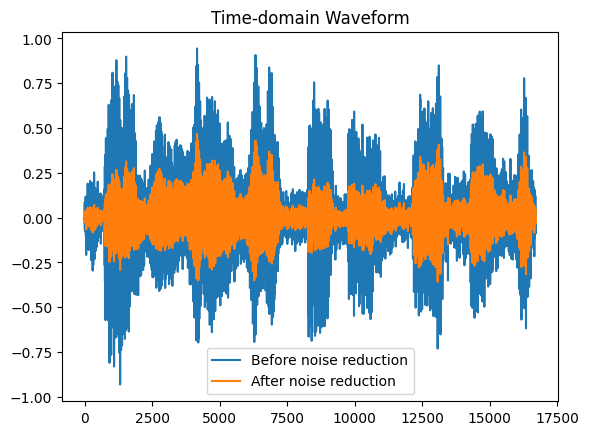

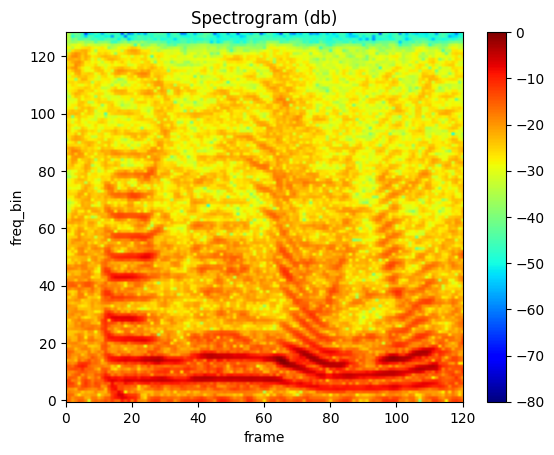

In [9]:
###################### 测试结果 ######################
# 绘制时域波形
plt.plot(noised_waveform.squeeze().numpy(),label="Before noise reduction")#降噪前波形
plt.plot(waveform.squeeze().numpy(),label="After noise reduction")#降噪后波形
plt.legend()
plt.title("Time-domain Waveform")

# # 绘制原始含噪语音的语谱图
# noised_mag,_=spectrogram(noised_waveform)
# plot_spectrogram(noised_mag,xmax=120)

# 绘制降噪后语音的语谱图
mag,_=spectrogram(waveform)
plot_spectrogram(mag,xmax=120)

# 播放降噪前的语音
play_audio(noised_waveform,8000) 

# 播放降噪后的语音
play_audio(waveform,8000)  